# Linear Spin-Wave Theory for the $J_1$-$J_2$ Spiral

Alur penurunan:

$$
H_{\rm spin}
\longrightarrow H_{\rm HP}^{(2)}
\longrightarrow \mathcal H_{\rm BdG}(q)
\longrightarrow \omega_n(q)
\longrightarrow S(q,\omega).
$$

**Objek matematis**

$$
U_r,F_{rs}\in\mathbb R^{3\times3},\qquad
A,\Delta\in\mathbb C^{M\times M},\qquad
\mathcal H_{\rm BdG}\in\mathbb C^{2M\times2M}.
$$

In [1]:
import numpy as np

## 1. Model aktif dan spiral klasik

Hamiltonian isotropik:

$$
H=\sum_i\left[J_1\,\mathbf S_i\cdot\mathbf S_{i+1}
+J_2\,\mathbf S_i\cdot\mathbf S_{i+2}\right].
$$

Ansatz spiral planar:

$$
\mathbf S_i^{\rm cl}=S(\sin Qi,0,\cos Qi).
$$

Energi klasik per situs:

$$
\frac{E_{\rm cl}(Q)}N
=S^2[J_1\cos Q+J_2\cos(2Q)].
$$

Syarat stasioner:

$$
\frac{1}{NS^2}\frac{dE_{\rm cl}}{dQ}
=-\sin Q(J_1+4J_2\cos Q)=0.
$$

Cabang spiral nonkolinear:

$$
\boxed{\cos Q=-\frac{J_1}{4J_2}},
\qquad J_2>0,\qquad |J_1|<4J_2.
$$

Untuk $\lambda=10$:

$$
Q=\frac{2\pi}{10},\qquad
J_2=-\frac{J_1}{4\cos Q}.
$$

**Parameter spiral klasik**

$$
Q=\frac{2\pi}{\lambda},\qquad
\cos Q=-\frac{J_1}{4J_2},\qquad
J_2=-\frac{J_1}{4\cos Q}>0.
$$

In [2]:
# Model parameters (lattice spacing a = 1)
wavelength = 10
J1 = -1.0
S = 1.0

# One magnetic unit cell contains one complete spiral period.
n_sites = wavelength
Q = 2.0 * np.pi / wavelength
J2 = -J1 / (4 * np.cos(Q))

assert wavelength >= 3
assert J2 > 0.0

print(f'J1 : {J1}')
print(f'J2 : {J2}')
print(f'Q : {Q}')
print(f'n_sites : {n_sites}')
print(f'S : {S}')


J1 : -1.0
J2 : 0.3090169943749474
Q : 0.6283185307179586
n_sites : 10
S : 1.0


**Sudut lokal tiap situs**

$$
\theta_r=Qr,\qquad \phi_r=0,\qquad r=0,\ldots,M-1.
$$

In [3]:
theta = Q * np.arange(n_sites) # phase angle
phi = np.zeros(n_sites) # azimuthal angle

**Matriks rotasi $U_r^{-1}$**

$$
U_r^{-1}=
\begin{pmatrix}
\cos\theta_r\cos\phi_r&-\sin\phi_r&\sin\theta_r\cos\phi_r\\
\cos\theta_r\sin\phi_r&\cos\phi_r&\sin\theta_r\sin\phi_r\\
-\sin\theta_r&0&\cos\theta_r
\end{pmatrix}.
$$

In [4]:
def local_to_global_rotation(theta, phi):
    # U_r^{-1}: local spin components -> global components.
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)

    return np.array([
        [cos_theta * cos_phi, -sin_phi, sin_theta * cos_phi],
        [cos_theta * sin_phi,  cos_phi, sin_theta * sin_phi],
        [-sin_theta,           0.0,     cos_theta]
    ])

**Sifat matriks rotasi**

$$
U_r=(U_r^{-1})^{\mathsf T},\qquad
U_rU_r^{-1}=I,\qquad
\det U_r^{-1}=1,
$$

$$
U_r^{-1}\hat{\mathbf z}=\hat{\mathbf n}_r
=(\sin\theta_r\cos\phi_r,\sin\theta_r\sin\phi_r,\cos\theta_r)^{\mathsf T}.
$$

In [5]:
# PDF notation:
# U_r^{-1}: local -> global
# U_r       : global -> local
U_inv = np.stack([
    local_to_global_rotation(theta[r], phi[r])
    for r in range(n_sites)
])
U = np.swapaxes(U_inv, 1, 2)

identity_3 = np.eye(3)
rotation_orthogonality_error = np.max(
    np.abs(U @ U_inv - identity_3)
)
rotation_determinant_error = np.max(
    np.abs(np.linalg.det(U_inv) - 1.0)
)

classical_direction = np.column_stack([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta)
])
local_z_alignment_error = np.max(
    np.abs(U_inv[:, :, 2] - classical_direction)
)

print("U_inv shape:", U_inv.shape)
print("U shape:", U.shape)
print("Maximum orthogonality error:", rotation_orthogonality_error)
print("Maximum det(U_inv) - 1 error:", rotation_determinant_error)
print("Maximum local-z alignment error:", local_z_alignment_error)

assert rotation_orthogonality_error < 1e-12
assert rotation_determinant_error < 1e-12
assert local_z_alignment_error < 1e-12

U_inv shape: (10, 3, 3)
U shape: (10, 3, 3)
Maximum orthogonality error: 2.220446049250313e-16
Maximum det(U_inv) - 1 error: 2.220446049250313e-16
Maximum local-z alignment error: 0.0


**Rotasi relatif ikatan**

$$
\boxed{F_{rs}=U_rU_s^{-1}}
=(U_r^{-1})^{\mathsf T}U_s^{-1}.
$$

In [6]:
def F_rs(U, U_inv, r, s):
    # F_rs = U_r @ U_s^{-1}, exactly as written in the PDF.
    return U[r] @ U_inv[s]

**Ikatan tetangga terdekat**

$$
F_{r,r+1}=U_rU_{r+1}^{-1}=R_y(Q).
$$

In [7]:
F_J1 = np.empty((n_sites, 3, 3))

for r in range(n_sites):
    s = (r + 1) % n_sites
    F_J1[r] = F_rs(U, U_inv, r, s)

**Ikatan tetangga kedua**

$$
F_{r,r+2}=U_rU_{r+2}^{-1}=R_y(2Q).
$$

In [8]:
F_J2 = np.empty((n_sites, 3, 3))

for r in range(n_sites):
    s = (r + 2) % n_sites
    F_J2[r] = F_rs(U, U_inv, r, s)

**Bentuk rotasi relatif**

$$
F_{r,r+d}=
\begin{pmatrix}
\cos(dQ)&0&\sin(dQ)\\
0&1&0\\
-\sin(dQ)&0&\cos(dQ)
\end{pmatrix}.
$$

In [9]:
print("F J1:")
print(F_J1[0])

print("\nF J2:")
print(F_J2[0])

F J1:
[[ 0.80901699  0.          0.58778525]
 [ 0.          1.          0.        ]
 [-0.58778525  0.          0.80901699]]

F J2:
[[ 0.30901699  0.          0.95105652]
 [ 0.          1.          0.        ]
 [-0.95105652  0.          0.30901699]]


**Dekomposisi Hamiltonian kuadratik**

$$
H_2=E_{\rm cl}+a^\dagger Aa
+\frac12\left(a^{\mathsf T}Ba+\text{h.c.}\right)+H_1.
$$

In [10]:
A_hp = np.zeros(
    (n_sites, n_sites),
    dtype=complex
)

B_hp = np.zeros(
    (n_sites, n_sites),
    dtype=complex
)

linear_hp = np.zeros(
    n_sites,
    dtype=complex
)

E_classical = 0.0

**Koefisien Holstein-Primakoff satu ikatan**

$$
E_{rs}=JS^2F_{zz},\qquad \varepsilon_{rs}=-JSF_{zz},
$$

$$
h_r=JS\sqrt{\frac S2}(F_{xz}-iF_{yz}),
$$

$$
T_{rs}=\frac{JS}{2}[F_{xx}+F_{yy}+i(F_{yx}-F_{xy})],
$$

$$
P_{rs}=\frac{JS}{2}[F_{xx}-F_{yy}-i(F_{xy}+F_{yx})].
$$

In [11]:
def add_hp_bond(A, B, linear, r, s, J, F, S):
    """
    Add one physical bond

        H_rs = J * S_tilde_r^T @ F_rs @ S_tilde_s

    through quadratic Holstein-Primakoff order.
    """

    # --------------------------------------------------------
    # Extract components of F_rs
    # --------------------------------------------------------

    F_xx = F[0, 0]
    F_xy = F[0, 1]
    F_xz = F[0, 2]

    F_yx = F[1, 0]
    F_yy = F[1, 1]
    F_yz = F[1, 2]

    F_zx = F[2, 0]
    F_zy = F[2, 1]
    F_zz = F[2, 2]

    # --------------------------------------------------------
    # Classical energy:
    #
    # E_rs = J S^2 F_zz
    # --------------------------------------------------------

    E_bond = J * S**2 * F_zz

    # --------------------------------------------------------
    # Linear terms:
    #
    # H1 = sum_r [
    #          linear[r] a_r
    #        + linear[r]^* a_r^dagger
    #      ]
    # --------------------------------------------------------

    sqrt_S_over_2 = np.sqrt(S / 2.0)

    linear[r] += (
        J
        * S
        * sqrt_S_over_2
        * (F_xz - 1j * F_yz)
    )

    linear[s] += (
        J
        * S
        * sqrt_S_over_2
        * (F_zx - 1j * F_zy)
    )

    # --------------------------------------------------------
    # Longitudinal zz contribution:
    #
    # J F_zz Sz_r Sz_s
    #
    # -> J S^2 F_zz
    #    - J S F_zz (n_r + n_s)
    # --------------------------------------------------------

    onsite = -J * S * F_zz

    A[r, r] += onsite
    A[s, s] += onsite

    # --------------------------------------------------------
    # Normal term:
    #
    # hopping a_r^dagger a_s
    # + hopping^* a_s^dagger a_r
    # --------------------------------------------------------

    hopping = (
        0.5
        * J
        * S
        * (
            F_xx
            + F_yy
            + 1j * (F_yx - F_xy)
        )
    )

    A[r, s] += hopping
    A[s, r] += np.conj(hopping)

    # --------------------------------------------------------
    # Pairing term:
    #
    # pairing a_r a_s
    # + pairing^* a_r^dagger a_s^dagger
    # --------------------------------------------------------

    pairing = (
        0.5
        * J
        * S
        * (
            F_xx
            - F_yy
            - 1j * (F_xy + F_yx)
        )
    )

    # B must satisfy B^T = B.
    B[r, s] += pairing
    B[s, r] += pairing

    return E_bond

**Kontribusi ikatan $J_1$**

$$
H_{J_1}=J_1\sum_{r=0}^{M-1}\mathbf S_r\cdot\mathbf S_{r+1},
\qquad s=r+1\pmod M.
$$

In [12]:
for r in range(n_sites):
    s = (r + 1) % n_sites

    E_classical += add_hp_bond(
        A=A_hp,
        B=B_hp,
        linear=linear_hp,
        r=r,
        s=s,
        J=J1,
        F=F_J1[r],
        S=S
    )

**Kontribusi ikatan $J_2$**

$$
H_{J_2}=J_2\sum_{r=0}^{M-1}\mathbf S_r\cdot\mathbf S_{r+2},
\qquad s=r+2\pmod M.
$$

In [13]:
for r in range(n_sites):
    s = (r + 2) % n_sites

    E_classical += add_hp_bond(
        A=A_hp,
        B=B_hp,
        linear=linear_hp,
        r=r,
        s=s,
        J=J2,
        F=F_J2[r],
        S=S
    )

**Syarat konsistensi Hamiltonian**

$$
\frac{E_{\rm cl}}M=S^2[J_1\cos Q+J_2\cos(2Q)],\qquad H_1=0,
$$

$$
A=A^\dagger,\qquad B=B^{\mathsf T}.
$$

In [14]:
E_per_site = E_classical / n_sites

E_per_site_expected = (
    S**2
    * (
        J1 * np.cos(Q)
        + J2 * np.cos(2.0 * Q)
    )
)

linear_error = np.max(
    np.abs(linear_hp)
)

A_error = np.max(
    np.abs(A_hp - A_hp.conj().T)
)

B_error = np.max(
    np.abs(B_hp - B_hp.T)
)

print("\n================================")
print("HOLSTEIN-PRIMAKOFF HAMILTONIAN")
print("================================")

print("\nClassical energy:")
print(E_classical)

print("\nClassical energy per site:")
print(E_per_site)

print("\nExpected energy per site:")
print(E_per_site_expected)

print("\nMaximum linear coefficient:")
print(linear_error)

print("\nA Hermiticity error:")
print(A_error)

print("\nB symmetry error:")
print(B_error)

assert np.allclose(
    E_per_site,
    E_per_site_expected
)

assert linear_error < 1e-12

assert np.allclose(
    A_hp,
    A_hp.conj().T
)

assert np.allclose(
    B_hp,
    B_hp.T
)


HOLSTEIN-PRIMAKOFF HAMILTONIAN

Classical energy:
-7.135254915624209

Classical energy per site:
-0.713525491562421

Expected energy per site:
-0.7135254915624212

Maximum linear coefficient:
1.3877787807814457e-16

A Hermiticity error:
0.0

B symmetry error:
0.0


**Matriks BdG ruang riil**

$$
\mathcal H_{\rm BdG}^{\rm real}=
\begin{pmatrix}A&B^*\\B&A^{\mathsf T}\end{pmatrix},
\qquad
\mathcal H_{\rm BdG}^{\rm real}
=(\mathcal H_{\rm BdG}^{\rm real})^\dagger.
$$

In [15]:
H_BdG_real = np.block([
    [
        A_hp,
        B_hp.conj()
    ],
    [
        B_hp,
        A_hp.T
    ]
])

print("\nReal-space BdG shape:")
print(H_BdG_real.shape)

bdg_error = np.max(
    np.abs(
        H_BdG_real
        - H_BdG_real.conj().T
    )
)

print("\nBdG Hermiticity error:")
print(bdg_error)

assert np.allclose(
    H_BdG_real,
    H_BdG_real.conj().T
)


Real-space BdG shape:
(20, 20)

BdG Hermiticity error:
0.0


## 2. Rotasi lokal dan ekspansi Holstein-Primakoff

### 2.1 Rotasi lokal

$$
\widetilde{\mathbf S}_r=U_r\mathbf S_r,
\qquad
\mathbf S_r=U_r^{-1}\widetilde{\mathbf S}_r.
$$

$$
U_r^{-1}=
\begin{pmatrix}
\cos\theta_r\cos\phi_r&-\sin\phi_r&\sin\theta_r\cos\phi_r\\
\cos\theta_r\sin\phi_r&\cos\phi_r&\sin\theta_r\sin\phi_r\\
-\sin\theta_r&0&\cos\theta_r
\end{pmatrix}.
$$

$$
U_r=(U_r^{-1})^{\mathsf T},\qquad
U_rU_r^{-1}=I,\qquad
\det U_r^{-1}=1.
$$

Untuk satu ikatan:

$$
J\mathbf S_r\cdot\mathbf S_s
=J\widetilde{\mathbf S}_r^{\mathsf T}
\underbrace{U_rU_s^{-1}}_{F_{rs}}
\widetilde{\mathbf S}_s.
$$

Untuk $\phi_r=0$ dan $\theta_r=Qr$:

$$
F_{rs}=R_y(\Delta_{rs})=
\begin{pmatrix}
\cos\Delta_{rs}&0&\sin\Delta_{rs}\\
0&1&0\\
-\sin\Delta_{rs}&0&\cos\Delta_{rs}
\end{pmatrix},
\qquad \Delta_{rs}=Q(s-r).
$$

### 2.2 Ekspansi Holstein-Primakoff

$$
\widetilde S_r^z=S-a_r^\dagger a_r,
\qquad
\widetilde S_r^x=\sqrt{\frac S2}(a_r+a_r^\dagger),
\qquad
\widetilde S_r^y=-i\sqrt{\frac S2}(a_r-a_r^\dagger).
$$

Orde klasik:

$$
H_{rs}^{(0)}=JS^2F_{zz}.
$$

Orde linear:

$$
H_{rs}^{(1)}=h_ra_r+h_r^*a_r^\dagger
+h_sa_s+h_s^*a_s^\dagger,
$$

$$
h_r=JS\sqrt{\frac S2}(F_{xz}-iF_{yz}),\qquad
h_s=JS\sqrt{\frac S2}(F_{zx}-iF_{zy}).
$$

Untuk konfigurasi klasik stasioner:

$$
\sum_{\langle rs\rangle}H_{rs}^{(1)}=0.
$$

Orde kuadratik:

$$
H_{rs}^{(2)}=-JSF_{zz}(n_r+n_s)
+T_{rs}a_r^\dagger a_s+T_{rs}^*a_s^\dagger a_r
+P_{rs}a_ra_s+P_{rs}^*a_r^\dagger a_s^\dagger,
$$

$$
T_{rs}=\frac{JS}{2}
[F_{xx}+F_{yy}+i(F_{yx}-F_{xy})],
$$

$$
P_{rs}=\frac{JS}{2}
[F_{xx}-F_{yy}-i(F_{xy}+F_{yx})].
$$

Dengan

$$
\Psi=(a_0,\ldots,a_{M-1},a_0^\dagger,\ldots,a_{M-1}^\dagger)^{\mathsf T},
$$

diperoleh

$$
H_2=\frac12\Psi^\dagger
\begin{pmatrix}A&B^*\\B&A^{\mathsf T}\end{pmatrix}
\Psi+\text{konstanta}.
$$

**Konvensi matriks $L$**

$$
H=V^\dagger LV,qquad
H=\frac12\Psi^\dagger\mathcal H_{\rm BdG}\Psi
\quad\Longrightarrow\quad
L=\frac12\mathcal H_{\rm BdG}.
$$

In [16]:
L_pdf_real = 0.5 * H_BdG_real

**Koefisien ikatan berjarak $d$**

$$
\varepsilon_{rs}=-JSF_{zz},\qquad
T_{rs}=\frac{JS}{2}[F_{xx}+F_{yy}+i(F_{yx}-F_{xy})],
$$

$$
P_{rs}=\frac{JS}{2}[F_{xx}-F_{yy}-i(F_{xy}+F_{yx})].
$$

In [17]:
# ============================================================
# FOURIER-SPACE BOND TABLE
# ============================================================

M = n_sites

hp_bonds = []


def append_hp_bond(
    bond_list,
    r,
    s,
    distance,
    J,
    F,
    S
):
    """
    Store the quadratic HP coefficients of one physical bond.

    distance:
        Physical bond displacement.

        distance = 1 for J1
        distance = 2 for J2
    """

    F_xx = F[0, 0]
    F_xy = F[0, 1]
    F_yx = F[1, 0]
    F_yy = F[1, 1]
    F_zz = F[2, 2]

    onsite = -J * S * F_zz

    hopping = (
        0.5
        * J
        * S
        * (
            F_xx
            + F_yy
            + 1j * (F_yx - F_xy)
        )
    )

    pairing = (
        0.5
        * J
        * S
        * (
            F_xx
            - F_yy
            - 1j * (F_xy + F_yx)
        )
    )

    bond_list.append({
        "r": r,
        "s": s,
        "distance": distance,
        "J": J,
        "onsite": onsite,
        "hopping": hopping,
        "pairing": pairing
    })

**Fase Fourier ikatan $J_1$**

$$
d=1,\qquad e^{-iqd}=e^{-iq},\qquad s=r+1\pmod M.
$$

In [18]:
for r in range(M):
    s = (r + 1) % M

    append_hp_bond(
        bond_list=hp_bonds,
        r=r,
        s=s,
        distance=1,
        J=J1,
        F=F_J1[r],
        S=S
    )

**Fase Fourier ikatan $J_2$**

$$
d=2,\qquad e^{-iqd}=e^{-i2q},\qquad s=r+2\pmod M.
$$

In [19]:
for r in range(M):
    s = (r + 2) % M

    append_hp_bond(
        bond_list=hp_bonds,
        r=r,
        s=s,
        distance=2,
        J=J2,
        F=F_J2[r],
        S=S
    )

**Jumlah ikatan dalam satu sel magnetik**

$$
N_{\rm bond}=M_{J_1}+M_{J_2}=2M.
$$

In [20]:
print("Number of physical HP bonds:")
print(len(hp_bonds))

assert len(hp_bonds) == 2 * M

Number of physical HP bonds:
20


**Blok Fourier $A(q)$ dan $\Delta(q)$**

Untuk ikatan $(r,s=r+d)$,

$$
A_{rr},A_{ss}\;\mathrel{+}=\varepsilon_{rs},
$$

$$
A_{rs}(q)\;\mathrel{+}=T_{rs}e^{-iqd},\qquad
A_{sr}(q)\;\mathrel{+}=T_{rs}^*e^{iqd},
$$

$$
\Delta_{rs}(q)\;\mathrel{+}=P_{rs}^*e^{-iqd},\qquad
\Delta_{sr}(q)\;\mathrel{+}=P_{rs}^*e^{iqd}.
$$

In [21]:
# ============================================================
# FOURIER BLOCKS A(q) AND DELTA(q)
# ============================================================

def build_fourier_blocks(q, M, hp_bonds):
    """
    Build A(q) and Delta(q).

    Fourier convention:

        a_x = 1/sqrt(N) sum_q exp(-i q x) a_q

    Therefore a forward bond of length d carries exp(-i q d).
    """

    A_q = np.zeros(
        (M, M),
        dtype=complex
    )

    Delta_q = np.zeros(
        (M, M),
        dtype=complex
    )

    for bond in hp_bonds:
        r = bond["r"]
        s = bond["s"]
        distance = bond["distance"]

        onsite = bond["onsite"]
        hopping = bond["hopping"]
        pairing = bond["pairing"]

        phase_forward = np.exp(
            -1j * q * distance
        )

        phase_backward = np.conj(
            phase_forward
        )

        # ----------------------------------------------------
        # Onsite number operators
        # ----------------------------------------------------

        A_q[r, r] += onsite
        A_q[s, s] += onsite

        # ----------------------------------------------------
        # Normal/hopping block
        #
        # T_rs exp(-iqd) a_qr^dagger a_qs
        # + h.c.
        # ----------------------------------------------------

        normal_forward = (
            hopping
            * phase_forward
        )

        A_q[r, s] += normal_forward
        A_q[s, r] += np.conj(
            normal_forward
        )

        # ----------------------------------------------------
        # Creation-pairing block
        #
        # P_rs^* exp(-iqd)
        # a_qr^dagger a_-q,s^dagger
        # ----------------------------------------------------

        Delta_q[r, s] += (
            np.conj(pairing)
            * phase_forward
        )

        Delta_q[s, r] += (
            np.conj(pairing)
            * phase_backward
        )

    return A_q, Delta_q

**Simetri blok Fourier**

$$
A(q)=A^\dagger(q),\qquad
\Delta^{\mathsf T}(q)=\Delta(-q).
$$

In [22]:
q_test = 0.3

A_test, Delta_test = build_fourier_blocks(
    q=q_test,
    M=M,
    hp_bonds=hp_bonds
)

A_minus_test, Delta_minus_test = build_fourier_blocks(
    q=-q_test,
    M=M,
    hp_bonds=hp_bonds
)

A_test_error = np.max(
    np.abs(
        A_test
        - A_test.conj().T
    )
)

Delta_test_error = np.max(
    np.abs(
        Delta_test.T
        - Delta_minus_test
    )
)

print("\nA(q) Hermiticity error:")
print(A_test_error)

print("\nDelta(q)^T - Delta(-q) error:")
print(Delta_test_error)

assert np.allclose(
    A_test,
    A_test.conj().T
)

assert np.allclose(
    Delta_test.T,
    Delta_minus_test
)


A(q) Hermiticity error:
0.0

Delta(q)^T - Delta(-q) error:
0.0


**Hamiltonian BdG pada momentum $q$**

$$
\boxed{
\mathcal H_{\rm BdG}(q)=
\begin{pmatrix}
A(q)&\Delta(q)\\
\Delta^\dagger(q)&A^{\mathsf T}(-q)
\end{pmatrix}}
$$

In [23]:
# ============================================================
# BOSONIC BdG HAMILTONIAN
# ============================================================

def build_bdg_hamiltonian(q, M, hp_bonds):
    """
    Return the standard bosonic BdG matrix H_BdG(q):

              [ A(q)          Delta(q)   ]
        H  =  [                          ]
              [ Delta(q)^dag  A(-q)^T    ]

    with:

        H2 = 1/2 sum_q Psi_q^dag H_BdG(q) Psi_q + C
    """

    A_q, Delta_q = build_fourier_blocks(
        q=q,
        M=M,
        hp_bonds=hp_bonds
    )

    A_minus_q, _ = build_fourier_blocks(
        q=-q,
        M=M,
        hp_bonds=hp_bonds
    )

    H_BdG_q = np.block([
        [
            A_q,
            Delta_q
        ],
        [
            Delta_q.conj().T,
            A_minus_q.T
        ]
    ])

    return H_BdG_q

**Dimensi dan Hermitisitas BdG**

$$
\mathcal H_{\rm BdG}(q)\in\mathbb C^{2M\times2M},\qquad
\mathcal H_{\rm BdG}(q)=\mathcal H_{\rm BdG}^\dagger(q).
$$

In [24]:
H_test = build_bdg_hamiltonian(
    q=q_test,
    M=M,
    hp_bonds=hp_bonds
)

print("\nBdG matrix shape:")
print(H_test.shape)

H_test_error = np.max(
    np.abs(
        H_test
        - H_test.conj().T
    )
)

print("\nBdG Hermiticity error:")
print(H_test_error)

assert H_test.shape == (2 * M, 2 * M)

assert np.allclose(
    H_test,
    H_test.conj().T
)


BdG matrix shape:
(20, 20)

BdG Hermiticity error:
0.0


**Diagonalization Colpa**

$$
\mathcal H_\epsilon=\mathcal H_{\rm BdG}+\epsilon I=K^\dagger K,
\qquad G=K\Sigma_zK^\dagger,
$$

$$
Gu_n=\omega_nu_n,\qquad
t_n=\sqrt{|\omega_n|}\,K^{-1}u_n,
$$

$$
\Sigma_z\mathcal H_\epsilon t_n=\omega_nt_n,qquad
T^\dagger\Sigma_zT=\Sigma_z.
$$

In [25]:
# ============================================================
# PARAUNITARY BOSONIC BOGOLIUBOV DIAGONALIZATION
# ============================================================

BDG_REGULARIZATION = 1.0e-10


def solve_bosonic_bdg_colpa(
    q,
    M,
    hp_bonds,
    Sigma_z,
    regularization=BDG_REGULARIZATION
):
    """
    Diagonalize a positive-semidefinite bosonic BdG Hamiltonian
    using a small regularization and the Colpa construction.

    The returned columns satisfy the bosonic metric:

        T^dagger Sigma_z T = Sigma_z
    """

    H_BdG_q = build_bdg_hamiltonian(
        q=q,
        M=M,
        hp_bonds=hp_bonds
    )

    dimension = 2 * M

    # --------------------------------------------------------
    # 1. Regularize the exact Goldstone modes
    # --------------------------------------------------------

    H_regularized = (
        H_BdG_q
        + regularization
        * np.eye(
            dimension,
            dtype=complex
        )
    )

    # --------------------------------------------------------
    # 2. Cholesky factorization
    #
    # NumPy returns:
    #
    #     H = L L^dagger
    #
    # We need:
    #
    #     H = K^dagger K
    #
    # Therefore K = L^dagger.
    # --------------------------------------------------------

    try:
        lower_cholesky = np.linalg.cholesky(
            H_regularized
        )

    except np.linalg.LinAlgError as error:
        raise RuntimeError(
            "BdG Hamiltonian is not positive definite after "
            "regularization. The classical state may be unstable."
        ) from error

    K = lower_cholesky.conj().T

    # --------------------------------------------------------
    # 3. Construct the Hermitian Colpa matrix
    #
    #     G = K Sigma_z K^dagger
    # --------------------------------------------------------

    G = (
        K
        @ Sigma_z
        @ K.conj().T
    )

    G_hermiticity_error = np.max(
        np.abs(
            G
            - G.conj().T
        )
    )

    # --------------------------------------------------------
    # 4. Ordinary Hermitian eigendecomposition
    #
    # np.linalg.eigh returns sorted real eigenvalues.
    # --------------------------------------------------------

    energies, unitary_vectors = np.linalg.eigh(
        G
    )

    # --------------------------------------------------------
    # 5. Transform back to BdG eigenvectors
    #
    #     t_n = sqrt(|omega_n|) K^{-1} u_n
    # --------------------------------------------------------

    bdg_vectors = np.linalg.solve(
        K,
        unitary_vectors
    )

    bdg_vectors *= np.sqrt(
        np.abs(energies)
    )[None, :]

    # eigh orders the spectrum as:
    #
    # negative energies first, then positive energies.
    negative_energies = energies[:M]
    positive_energies = energies[M:]

    negative_vectors = bdg_vectors[:, :M]
    positive_vectors = bdg_vectors[:, M:]

    # --------------------------------------------------------
    # 6. Reorder columns into conventional paraunitary order:
    #
    # positive-norm columns first,
    # negative-norm columns second.
    # --------------------------------------------------------

    T_paraunitary = np.hstack([
        positive_vectors,
        negative_vectors
    ])

    ordered_energies = np.concatenate([
        positive_energies,
        negative_energies
    ])

    # --------------------------------------------------------
    # 7. Bosonic metric validation
    #
    # T^dagger Sigma_z T must equal Sigma_z.
    # --------------------------------------------------------

    metric_matrix = (
        T_paraunitary.conj().T
        @ Sigma_z
        @ T_paraunitary
    )

    metric_error = np.max(
        np.abs(
            metric_matrix
            - Sigma_z
        )
    )

    # --------------------------------------------------------
    # 8. Eigenvalue-equation residual
    #
    # Sigma_z H t_n = omega_n t_n
    # --------------------------------------------------------

    dynamic_matrix = (
        Sigma_z
        @ H_regularized
    )

    residual_matrix = (
        dynamic_matrix
        @ bdg_vectors
        - bdg_vectors
        * energies[None, :]
    )

    residual_error = np.max(
        np.abs(
            residual_matrix
        )
    )

    # --------------------------------------------------------
    # 9. Paraunitary inverse
    #
    # T^{-1} = Sigma_z T^dagger Sigma_z
    # --------------------------------------------------------

    T_inverse = (
        Sigma_z
        @ T_paraunitary.conj().T
        @ Sigma_z
    )

    inverse_error = np.max(
        np.abs(
            T_inverse
            @ T_paraunitary
            - np.eye(dimension)
        )
    )

    return {
        "hamiltonian": H_BdG_q,
        "regularized_hamiltonian": H_regularized,
        "positive_energies": positive_energies,
        "negative_energies": negative_energies,
        "positive_vectors": positive_vectors,
        "negative_vectors": negative_vectors,
        "T": T_paraunitary,
        "T_inverse": T_inverse,
        "ordered_energies": ordered_energies,
        "metric_matrix": metric_matrix,
        "G_hermiticity_error": G_hermiticity_error,
        "metric_error": metric_error,
        "residual_error": residual_error,
        "inverse_error": inverse_error
    }

**Relasi $L(q)$ dan $\mathcal H_{\rm BdG}(q)$**

$$
L(q)=\frac12\mathcal H_{\rm BdG}(q).
$$

In [26]:
def build_L_pdf(q, M, hp_bonds):
    return 0.5 * build_bdg_hamiltonian(
        q=q,
        M=M,
        hp_bonds=hp_bonds
    )

**Metrik bosonik**

$$
\Sigma_z=
\begin{pmatrix}I_M&0\\0&-I_M\end{pmatrix}.
$$

In [27]:
Sigma_z = np.diag(
    np.concatenate([
        np.ones(M),
        -np.ones(M)
    ])
)

**Persamaan dinamik bosonik**

$$
D(q)=\Sigma_z\mathcal H_{\rm BdG}(q),\qquad
D(q)v_n(q)=\omega_n(q)v_n(q).
$$

Untuk keadaan stabil,

$$
\Im\omega_n=0,\qquad
\omega_{2M+1-n}=-\omega_n.
$$

In [28]:
def solve_bosonic_bdg(q, M, hp_bonds, Sigma_z):
    """
    Solve:

        Sigma_z @ H_BdG(q) @ v_n = omega_n @ v_n

    Returns all 2M eigenvalues and the M nonnegative branches.
    """

    H_BdG_q = build_bdg_hamiltonian(
        q=q,
        M=M,
        hp_bonds=hp_bonds
    )

    dynamic_matrix = (
        Sigma_z
        @ H_BdG_q
    )

    eigenvalues, eigenvectors = np.linalg.eig(
        dynamic_matrix
    )

    maximum_imaginary = np.max(
        np.abs(eigenvalues.imag)
    )

    order = np.argsort(
        eigenvalues.real
    )

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    real_eigenvalues = eigenvalues.real

    # For a stable 2M-dimensional bosonic BdG problem,
    # the upper half contains the M nonnegative branches.
    positive_energies = real_eigenvalues[M:]

    # Remove tiny negative round-off around Goldstone points.
    positive_energies = np.clip(
        positive_energies,
        0.0,
        None
    )

    pairing_error = np.max(
        np.abs(
            real_eigenvalues
            + real_eigenvalues[::-1]
        )
    )

    return {
        "hamiltonian": H_BdG_q,
        "all_energies": real_eigenvalues,
        "positive_energies": positive_energies,
        "eigenvectors": eigenvectors,
        "maximum_imaginary": maximum_imaginary,
        "pairing_error": pairing_error
    }

**Spektrum pada satu momentum**

$$
\operatorname{spec}D(q)=
\{-\omega_M,\ldots,-\omega_1,\omega_1,\ldots,\omega_M\},
\qquad \omega_n\ge0.
$$

In [29]:
solution_test = solve_bosonic_bdg(
    q=q_test,
    M=M,
    hp_bonds=hp_bonds,
    Sigma_z=Sigma_z
)

print("\nAll BdG energies:")
print(solution_test["all_energies"])

print("\nPositive magnon energies:")
print(solution_test["positive_energies"])

print("\nMaximum imaginary part:")
print(solution_test["maximum_imaginary"])

print("\nPositive-negative pairing error:")
print(solution_test["pairing_error"])


All BdG energies:
[-3.47064086 -3.44209272 -2.39630928 -2.33337814 -1.0269184  -0.97338204
 -0.16977844 -0.14822905 -0.03305601 -0.03208849  0.03208849  0.03305601
  0.14822905  0.16977844  0.97338204  1.0269184   2.33337814  2.39630928
  3.44209272  3.47064086]

Positive magnon energies:
[0.03208849 0.03305601 0.14822905 0.16977844 0.97338204 1.0269184
 2.33337814 2.39630928 3.44209272 3.47064086]

Maximum imaginary part:
3.287435297140472e-16

Positive-negative pairing error:
1.4210854715202004e-14


## 3. Transformasi Fourier dan bosonic BdG

$$
a_{n,r}=\frac1{\sqrt{N_c}}\sum_qe^{-iq(R_n+r)}a_{q,r},
\qquad
a_{q,r}=\frac1{\sqrt{N_c}}\sum_ne^{iq(R_n+r)}a_{n,r}.
$$

$$
\sum_ne^{i(q-q')R_n}=N_c\delta_{q,q'},\qquad
\sum_ne^{i(q+q')R_n}=N_c\delta_{q,-q'}.
$$

Untuk ikatan maju berjarak $d$:

$$
a_{n,r}^\dagger a_{n,s}\longrightarrow e^{-iqd}a_{q,r}^\dagger a_{q,s},
$$

$$
a_{n,r}a_{n,s}\longrightarrow e^{-iqd}a_{q,r}a_{-q,s}.
$$

$$
H_2=\frac12\sum_q\Psi_q^\dagger
\mathcal H_{\rm BdG}(q)\Psi_q+C,
$$

$$
\Psi_q=(a_{q,0},\ldots,a_{q,M-1},
a_{-q,0}^\dagger,\ldots,a_{-q,M-1}^\dagger)^{\mathsf T},
$$

$$
\mathcal H_{\rm BdG}(q)=
\begin{pmatrix}
A(q)&\Delta(q)\\
\Delta^\dagger(q)&A^{\mathsf T}(-q)
\end{pmatrix}.
$$

$$
A(q)=A^\dagger(q),\qquad
\Delta^{\mathsf T}(q)=\Delta(-q).
$$

Dengan

$$
\Sigma_z=\operatorname{diag}(I_M,-I_M),
$$

persamaan eigen bosonik adalah

$$
\boxed{\Sigma_z\mathcal H_{\rm BdG}(q)v_{nq}
=\omega_{nq}v_{nq}}.
$$

Normalisasi paraunitary:

$$
T_q^\dagger\Sigma_zT_q=\Sigma_z,
\qquad
T_q^{-1}=\Sigma_zT_q^\dagger\Sigma_z.
$$

Konstruksi Colpa:

$$
\mathcal H_\epsilon=K^\dagger K,qquad
G=K\Sigma_zK^\dagger,qquad
Gu_n=\omega_nu_n,
$$

$$
t_n=\sqrt{|\omega_n|}\,K^{-1}u_n.
$$

Validasi analitik:

$$
J(k)=J_1\cos k+J_2\cos(2k),
$$

$$
\omega_k=2S\sqrt{[J(k)-J(Q)]
\left[\frac{J(k+Q)+J(k-Q)}2-J(Q)\right]},
$$

$$
k=q+\frac{2\pi m}{M},\qquad m=0,\ldots,M-1.
$$

**Dispersi pada ruang momentum**

$$
q_j\in[0,3\pi],\qquad
\omega_n(q_j),\quad n=1,\ldots,M.
$$

In [30]:
# ============================================================
# COMPLETE DISPERSION
# ============================================================

# Extended momentum range: 1.5 structural Brillouin zones.
# The M folded bands repeat every magnetic reciprocal vector 2*pi/M.
q_min = 0.0
q_max = 3.0 * np.pi
n_q = 150

q_values = np.linspace(
    q_min,
    q_max,
    n_q
)

all_energies = np.zeros(
    (n_q, 2 * M)
)

positive_energies = np.zeros(
    (n_q, M)
)

maximum_hermiticity_error = 0.0
maximum_imaginary_energy = 0.0
maximum_pairing_error = 0.0


for iq, q in enumerate(q_values):
    solution = solve_bosonic_bdg(
        q=q,
        M=M,
        hp_bonds=hp_bonds,
        Sigma_z=Sigma_z
    )

    H_q = solution["hamiltonian"]

    all_energies[iq] = solution[
        "all_energies"
    ]

    positive_energies[iq] = solution[
        "positive_energies"
    ]

    maximum_hermiticity_error = max(
        maximum_hermiticity_error,
        np.max(
            np.abs(
                H_q
                - H_q.conj().T
            )
        )
    )

    maximum_imaginary_energy = max(
        maximum_imaginary_energy,
        solution["maximum_imaginary"]
    )

    maximum_pairing_error = max(
        maximum_pairing_error,
        solution["pairing_error"]
    )


print("\n================================")
print("DISPERSION VALIDATION")
print("================================")

print("\nMaximum BdG Hermiticity error:")
print(maximum_hermiticity_error)

print("\nMaximum imaginary eigenvalue:")
print(maximum_imaginary_energy)

print("\nMaximum +/- pairing error:")
print(maximum_pairing_error)

assert maximum_hermiticity_error < 1e-12
assert maximum_imaginary_energy < 1e-7
assert maximum_pairing_error < 1e-10


DISPERSION VALIDATION

Maximum BdG Hermiticity error:
0.0

Maximum imaginary eigenvalue:
5.218108808310306e-09

Maximum +/- pairing error:
2.4424906541753444e-14


**Dispersi analitik spiral**

$$
J(k)=J_1\cos k+J_2\cos(2k),
$$

$$
\omega_k=2S\sqrt{[J(k)-J(Q)]
\left[\frac{J(k+Q)+J(k-Q)}2-J(Q)\right]},
$$

$$
k=q+\frac{2\pi m}{M},\qquad m=0,\ldots,M-1.
$$

In [31]:
def exchange_fourier(k):
    return (
        J1 * np.cos(k) + J2 * np.cos(2.0 * k)
    )


def analytic_folded_energies(q, M, S):
    """Return sorted folded branches for scalar or array-like q."""
    q = np.atleast_1d(np.asarray(q, dtype=float))
    m_values = np.arange(M)
    k_values = (
        q[:, None] + 2.0 * np.pi * m_values[None, :] / M
    )

    exchange_at_Q = exchange_fourier(Q)
    first_factor = exchange_fourier(k_values) - exchange_at_Q

    second_factor = (
        0.5
        * (
            exchange_fourier(k_values + Q)
            + exchange_fourier(k_values - Q)
        )
        - exchange_at_Q
    )

    omega_squared = (
        4.0
        * S**2
        * first_factor
        * second_factor
    )

    # Remove tiny negative values caused by floating-point error.
    omega_squared = np.clip(
        omega_squared,
        0.0,
        None
    )

    energies = np.sort(np.sqrt(omega_squared), axis=-1)
    return energies[0] if q.size == 1 else energies

**Galat numerik terhadap solusi analitik**

$$
\epsilon_{\rm an}=
\max_{q,n}|\omega_n^{\rm BdG}(q)-\omega_n^{\rm analytic}(q)|.
$$

In [32]:
analytic_energies = analytic_folded_energies(
    q=q_values,
    M=M,
    S=S
)

maximum_analytic_error = np.max(
    np.abs(
        np.sort(positive_energies, axis=1)
        - analytic_energies
    )
)


print("\nMaximum numerical-analytic error:")
print(maximum_analytic_error)

assert maximum_analytic_error < 1e-7


Maximum numerical-analytic error:
4.5406533630574135e-09


**Cabang magnon dan mode Goldstone**

$$
\omega_n(q),\qquad n=1,\ldots,M,
\qquad \omega_{\rm G}(q_0)=0.
$$

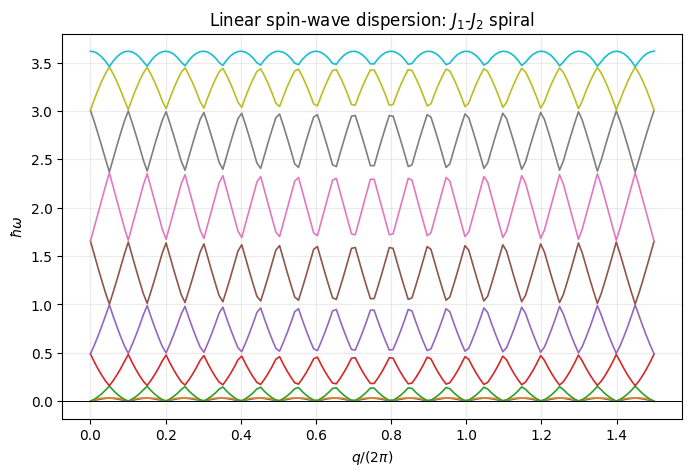

In [33]:
import matplotlib.pyplot as plt


q_over_2pi = (
    q_values
    / (2.0 * np.pi)
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

for mode in range(M):
    ax.plot(
        q_over_2pi,
        positive_energies[:, mode],
        linewidth=1.2
    )

ax.set_xlabel(
    r"$q/(2\pi)$"
)

ax.set_ylabel(
    r"$\hbar\omega$"
)

ax.set_title(
    r"Linear spin-wave dispersion: $J_1$-$J_2$ spiral"
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.7
)

ax.grid(
    alpha=0.25
)

plt.show()

**Identitas Colpa**

$$
G=G^\dagger,\qquad
T^\dagger\Sigma_zT=\Sigma_z,
$$

$$
\Sigma_z\mathcal H_\epsilon T=T\Omega,
\qquad
T^{-1}=\Sigma_zT^\dagger\Sigma_z.
$$

In [34]:
q_test = 0.3

colpa_test = solve_bosonic_bdg_colpa(
    q=q_test,
    M=M,
    hp_bonds=hp_bonds,
    Sigma_z=Sigma_z
)

print("\n================================")
print("COLPA / PARAUNITARY TEST")
print("================================")

print("\nPositive energies:")
print(
    colpa_test["positive_energies"]
)

print("\nNegative energies:")
print(
    colpa_test["negative_energies"]
)

print("\nColpa G Hermiticity error:")
print(
    colpa_test["G_hermiticity_error"]
)

print("\nParaunitary metric error:")
print(
    colpa_test["metric_error"]
)

print("\nEigenvalue residual error:")
print(
    colpa_test["residual_error"]
)

print("\nParaunitary inverse error:")
print(
    colpa_test["inverse_error"]
)


COLPA / PARAUNITARY TEST

Positive energies:
[0.03208849 0.03305601 0.14822905 0.16977844 0.97338204 1.0269184
 2.33337814 2.39630928 3.44209272 3.47064086]

Negative energies:
[-3.47064086 -3.44209272 -2.39630928 -2.33337814 -1.0269184  -0.97338204
 -0.16977844 -0.14822905 -0.03305601 -0.03208849]

Colpa G Hermiticity error:
0.0

Paraunitary metric error:
6.439293542825908e-15

Eigenvalue residual error:
5.208332100269165e-15

Paraunitary inverse error:
6.439293542825908e-15


**Norma mode positif**

$$
V_+^\dagger\Sigma_zV_+=I_M.
$$

In [35]:
positive_vectors_test = colpa_test[
    "positive_vectors"
]

positive_metric = (
    positive_vectors_test.conj().T
    @ Sigma_z
    @ positive_vectors_test
)

print("\nPositive-mode metric:")
print(
    np.real_if_close(
        positive_metric
    )
)

assert np.allclose(
    positive_metric,
    np.eye(M),
    atol=1e-8
)


Positive-mode metric:
[[ 1.00000000e+00 -1.36555712e-15 -2.17261548e-15  2.46438218e-15
   1.54746916e-15 -1.09573094e-15  1.23792819e-16 -1.29127215e-16
  -6.67684386e-16  3.46457373e-16]
 [-1.36555712e-15  1.00000000e+00 -1.11022302e-16  3.73906215e-15
  -4.89303957e-16 -1.68313058e-15  1.68082240e-16 -1.15930926e-15
  -1.21834727e-16  6.89692150e-16]
 [-2.17261548e-15 -1.11022302e-16  1.00000000e+00 -1.03979761e-15
  -3.12572138e-16  8.71866349e-16  5.07101572e-16  1.24904044e-15
   1.00186182e-17  3.01834203e-16]
 [ 2.46438218e-15  3.73906215e-15 -1.03979761e-15  1.00000000e+00
   4.44089210e-16 -6.49695031e-16  8.81466619e-18 -6.13515478e-16
  -7.01367542e-16  5.33847027e-16]
 [ 1.54746916e-15 -4.89303957e-16 -3.12572138e-16  4.44089210e-16
   1.00000000e+00  3.85855207e-16  1.46067657e-16  3.65886153e-16
  -1.93211850e-16 -2.21696960e-16]
 [-1.09573094e-15 -1.68313058e-15  8.71866349e-16 -6.49695031e-16
   3.85855207e-16  1.00000000e+00  5.55111512e-16  1.69885254e-16
   2.08332

**Norma mode negatif**

$$
V_-^\dagger\Sigma_zV_-=-I_M.
$$

In [36]:
negative_vectors_test = colpa_test[
    "negative_vectors"
]

negative_metric = (
    negative_vectors_test.conj().T
    @ Sigma_z
    @ negative_vectors_test
)

assert np.allclose(
    negative_metric,
    -np.eye(M),
    atol=1e-8
)

**Ortogonalitas particle-hole**

$$
V_+^\dagger\Sigma_zV_-=0.
$$

In [37]:
cross_metric = (
    positive_vectors_test.conj().T
    @ Sigma_z
    @ negative_vectors_test
)

assert np.allclose(
    cross_metric,
    np.zeros((M, M)),
    atol=1e-8
)

**Syarat paraunitary untuk setiap $q$**

$$
\Sigma_z\mathcal H_\epsilon(q)V_+(q)
=V_+(q)\Omega_+(q),
$$

$$
V_+^\dagger(q)\Sigma_zV_+(q)=I_M.
$$

In [38]:
# Shape:
#
# q index, Nambu component, positive mode index

normalized_mode_vectors = np.zeros(
    (n_q, 2 * M, M),
    dtype=complex
)

colpa_positive_energies = np.zeros(
    (n_q, M)
)

maximum_colpa_hermiticity_error = 0.0
maximum_metric_error = 0.0
maximum_residual_error = 0.0
maximum_inverse_error = 0.0


for iq, q in enumerate(q_values):
    result = solve_bosonic_bdg_colpa(
        q=q,
        M=M,
        hp_bonds=hp_bonds,
        Sigma_z=Sigma_z
    )

    normalized_mode_vectors[iq] = result[
        "positive_vectors"
    ]

    colpa_positive_energies[iq] = result[
        "positive_energies"
    ]

    maximum_colpa_hermiticity_error = max(
        maximum_colpa_hermiticity_error,
        result["G_hermiticity_error"]
    )

    maximum_metric_error = max(
        maximum_metric_error,
        result["metric_error"]
    )

    maximum_residual_error = max(
        maximum_residual_error,
        result["residual_error"]
    )

    maximum_inverse_error = max(
        maximum_inverse_error,
        result["inverse_error"]
    )


print("\n================================")
print("PARAUNITARY GRID VALIDATION")
print("================================")

print("\nMaximum Colpa Hermiticity error:")
print(maximum_colpa_hermiticity_error)

print("\nMaximum paraunitary metric error:")
print(maximum_metric_error)

print("\nMaximum eigenvalue residual:")
print(maximum_residual_error)

print("\nMaximum inverse error:")
print(maximum_inverse_error)

assert maximum_colpa_hermiticity_error < 1e-12
assert maximum_metric_error < 1e-8
assert maximum_residual_error < 1e-8
assert maximum_inverse_error < 1e-8


PARAUNITARY GRID VALIDATION

Maximum Colpa Hermiticity error:
0.0

Maximum paraunitary metric error:
2.7867197438524727e-10

Maximum eigenvalue residual:
1.5327572544521217e-11

Maximum inverse error:
2.7867197438524727e-10


**Dampak regularisasi Goldstone**

$$
\delta\omega_{\rm reg}=
\max_{q,n}|\omega_n^{(\epsilon)}(q)-\omega_n^{(0)}(q)|.
$$

In [39]:
regularization_energy_shift = np.max(
    np.abs(
        colpa_positive_energies
        - positive_energies
    )
)

print("\nMaximum regularization energy shift:")
print(regularization_energy_shift)

assert regularization_energy_shift < 1e-5


Maximum regularization energy shift:
4.206012760121285e-06


**Dekomposisi particle-hole**

$$
V_+(q)=
\begin{pmatrix}u(q)\\v(q)\end{pmatrix}.
$$

In [40]:
vectors_q = normalized_mode_vectors[iq]

u_q = vectors_q[:M, :]
v_q = vectors_q[M:, :]

**Indeks koefisien Bogoliubov**

$$
u(q),v(q)\in\mathbb C^{M\times M},
\qquad u_{rn},v_{rn}.
$$

In [41]:
print(u_q.shape)
print(v_q.shape)

(10, 10)
(10, 10)


**Satu mode Bogoliubov**

$$
\mathbf u_0=(u_{00},\ldots,u_{M-1,0})^{\mathsf T},\qquad
\mathbf v_0=(v_{00},\ldots,v_{M-1,0})^{\mathsf T}.
$$

In [42]:
n = 0

u_mode_n = u_q[:, n]
v_mode_n = v_q[:, n]

**Normalisasi bosonik per mode**

$$
\sum_{r=0}^{M-1}\left(|u_{rn}|^2-|v_{rn}|^2\right)=1.
$$

In [43]:
mode_norms = (
    np.sum(
        np.abs(u_q)**2,
        axis=0
    )
    - np.sum(
        np.abs(v_q)**2,
        axis=0
    )
)

print("\nBosonic norms of positive modes:")
print(mode_norms)

assert np.allclose(
    mode_norms,
    np.ones(M),
    atol=1e-8
)


Bosonic norms of positive modes:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Eigenvector Bogoliubov dan faktor struktur satu-magnon

$$
S_r^\alpha\simeq\sqrt{\frac S2}
[C_{r\alpha}^-a_r+C_{r\alpha}^+a_r^\dagger],
$$

$$
C_{r\alpha}^{\mp}=(U_r^{-1})_{\alpha x}
\mp i(U_r^{-1})_{\alpha y}.
$$

Untuk

$$
V_+(q)=\begin{pmatrix}u(q)\\v(q)\end{pmatrix},
$$

amplitudo satu-magnon adalah

$$
F_{\alpha n}(q)=\sqrt{\frac{S}{2M}}
\sum_{r=0}^{M-1}
[C_{r\alpha}^-u_{rn}(q)+C_{r\alpha}^+v_{rn}(q)].
$$

Tensor mode:

$$
S_n^{\alpha\beta}(q)=F_{\alpha n}(q)F_{\beta n}^*(q).
$$

$$
S_n^{\alpha\beta}=[S_n^{\beta\alpha}]^*,
\qquad
S_n^{\alpha\alpha}=|F_{\alpha n}|^2\ge0.
$$

Proyektor transversal:

$$
P_{\alpha\beta}=\delta_{\alpha\beta}-\hat q_\alpha\hat q_\beta.
$$

Intensitas satu mode:

$$
I_n(q)=\sum_{\alpha\beta}
P_{\alpha\beta}S_n^{\alpha\beta}(q).
$$

Broadening Gaussian:

$$
\delta_\sigma(x)=\frac{e^{-x^2/(2\sigma^2)}}{\sqrt{2\pi}\sigma},
$$

$$
S(q,\omega)=\sum_nI_n(q)
\delta_\sigma[\omega-\omega_n(q)].
$$

Aturan jumlah:

$$
\int S(q,\omega)\,d\omega=\sum_nI_n(q).
$$

**Amplitudo satu-magnon**

$$
C_{r\alpha}^{\mp}=(U_r^{-1})_{\alpha x}
\mp i(U_r^{-1})_{\alpha y},
$$

$$
F_{\alpha n}(q)=\sqrt{\frac{S}{2M}}
\sum_r[C_{r\alpha}^-u_{rn}(q)+C_{r\alpha}^+v_{rn}(q)],
$$

$$
S_n^{\alpha\beta}(q)=F_{\alpha n}(q)F_{\beta n}^*(q).
$$

In [44]:
def one_magnon_structure_factor(
    positive_vectors,
    rotations,
    S
):
    """
    Menghitung matrix element satu-magnon dan tensor S^{alpha beta}_n(q).

    Parameters
    ----------
    positive_vectors : ndarray, shape (..., 2*M, M)
        Eigenvector Bogoliubov energi positif untuk satu q atau grid q.
        Bagian Nambu atas adalah u, bagian bawah adalah v.

    rotations : ndarray, shape (M, 3, 3)
        Matriks U_r^{-1} untuk seluruh situs.

    S : float
        Besar spin.

    Returns
    -------
    total_amplitudes : ndarray, shape (..., 3, M)
        F_{alpha,n}(q).

    Sab_modes : ndarray, shape (..., 3, 3, M)
        Tensor S_n^{alpha,beta}(q) untuk setiap mode.
    """

    positive_vectors = np.asarray(positive_vectors)
    M = rotations.shape[0]
    single_q = positive_vectors.ndim == 2

    if single_q:
        positive_vectors = positive_vectors[None, ...]

    if positive_vectors.ndim != 3 or positive_vectors.shape[1:] != (2 * M, M):
        raise ValueError("positive_vectors harus berbentuk (..., 2*M, M).")

    # Bagian particle dan hole dari eigenvector Bogoliubov
    u = positive_vectors[:, :M, :]
    v = positive_vectors[:, M:, :]

    # C^-_{r,alpha} = U^{-1}_{alpha,x} - i U^{-1}_{alpha,y}
    c_minus = (
        rotations[:, :, 0]
        - 1j * rotations[:, :, 1]
    )

    # C^+_{r,alpha} = U^{-1}_{alpha,x} + i U^{-1}_{alpha,y}
    c_plus = (
        rotations[:, :, 0]
        + 1j * rotations[:, :, 1]
    )

    # F_{q,alpha,n}; einsum contracts all sites for the full q grid.
    prefactor = np.sqrt(S / (2.0 * M))
    total_amplitudes = prefactor * (
        np.einsum("ra,qrn->qan", c_minus, u, optimize=True)
        + np.einsum("ra,qrn->qan", c_plus, v, optimize=True)
    )

    # S_n^{alpha,beta}(q)
    Sab_modes = np.einsum(
        "qan,qbn->qabn",
        total_amplitudes,
        np.conj(total_amplitudes)
    )

    if single_q:
        return total_amplitudes[0], Sab_modes[0]

    return total_amplitudes, Sab_modes

**Dimensi faktor struktur satu momentum**

$$
F_{\alpha n}\in\mathbb C^{3\times M},\qquad
S_n^{\alpha\beta}\in\mathbb C^{3\times3\times M}.
$$

In [45]:
iq = 0

positive_vectors_q = normalized_mode_vectors[iq]

amplitudes_q, Sab_q = one_magnon_structure_factor(
    positive_vectors=positive_vectors_q,
    rotations=U_inv,
    S=S
)

print("amplitudes shape:", amplitudes_q.shape)
print("Sab shape:", Sab_q.shape)

amplitudes shape: (3, 10)
Sab shape: (3, 3, 10)


**Faktor struktur untuk seluruh momentum**

$$
S_n^{\alpha\beta}(q)=F_{\alpha n}(q)F_{\beta n}^*(q),
\qquad q\in\{q_j\}.
$$

In [46]:
n_q = len(q_values)
M = n_sites

mode_amplitudes, mode_tensors = one_magnon_structure_factor(
    positive_vectors=normalized_mode_vectors,
    rotations=U_inv,
    S=S
)

assert mode_amplitudes.shape == (n_q, 3, M)
assert mode_tensors.shape == (n_q, 3, 3, M)

**Hermitisitas tensor spin**

$$
S_n^{\alpha\beta}(q)=
[S_n^{\beta\alpha}(q)]^*.
$$

In [47]:
sab_hermiticity_error = np.max(
    np.abs(
        mode_tensors
        - np.swapaxes(
            np.conj(mode_tensors),
            1,
            2
        )
    )
)

print(
    "Maximum S tensor Hermiticity error:",
    sab_hermiticity_error
)

Maximum S tensor Hermiticity error: 6.938893903907228e-18


**Komponen diagonal tensor spin**

$$
S_n^{\alpha\alpha}(q)=|F_{\alpha n}(q)|^2\ge0,
\qquad \alpha\in\{x,y,z\}.
$$

In [48]:
diagonal_weights = np.stack(
    [
        mode_tensors[:, 0, 0, :],
        mode_tensors[:, 1, 1, :],
        mode_tensors[:, 2, 2, :]
    ],
    axis=1
)

maximum_diagonal_imaginary = np.max(
    np.abs(np.imag(diagonal_weights))
)

minimum_diagonal_weight = np.min(
    np.real(diagonal_weights)
)

print(
    "Maximum imaginary diagonal:",
    maximum_diagonal_imaginary
)

print(
    "Minimum diagonal weight:",
    minimum_diagonal_weight
)

Maximum imaginary diagonal: 5.75104746170798e-19
Minimum diagonal weight: 0.0


**Proyektor polarisasi neutron**

$$
\hat{\mathbf q}=\frac{\mathbf q}{|\mathbf q|},\qquad
P_{\alpha\beta}=\delta_{\alpha\beta}
-\hat q_\alpha\hat q_\beta.
$$

In [49]:
def neutron_polarization_tensor(q_hat):
    q_hat = np.asarray(q_hat, dtype=float)

    norm = np.linalg.norm(q_hat)

    if norm == 0:
        raise ValueError(
            "Arah q harus diberikan untuk limit q -> 0."
        )

    q_hat = q_hat / norm

    return (
        np.eye(3)
        - np.outer(q_hat, q_hat)
    )

**Intensitas mode neutron**

$$
I_n(q)=\sum_{\alpha,\beta}
P_{\alpha\beta}S_n^{\alpha\beta}(q).
$$

In [50]:
q_hat = np.array([1.0, 0.0, 0.0])

polarization = neutron_polarization_tensor(q_hat)

raw_neutron_mode_weights = np.einsum(
    "ab,qabn->qn",
    polarization,
    mode_tensors
).real

**Positivitas intensitas**

$$
I_n(q)\ge0.
$$

In [51]:
minimum_raw_weight = np.min(
    raw_neutron_mode_weights
)

print(
    "Minimum raw neutron weight:",
    minimum_raw_weight
)

Minimum raw neutron weight: 2.665654380360293e-35


**Koreksi galat pembulatan**

$$
\widetilde I_n(q)=\max[I_n(q),0],
\qquad I_n(q)\ge-10^{-10}.
$$

In [52]:
tolerance = 1e-10

if minimum_raw_weight < -tolerance:
    raise RuntimeError(
        "Ditemukan intensitas neutron negatif yang signifikan. "
        "Periksa normalisasi Bogoliubov."
    )

neutron_mode_weights = np.maximum(
    raw_neutron_mode_weights,
    0.0
)

**Skala intensitas spektral**

$$
C_n(q)=\log[1+I_n(q)],
\qquad (q,\omega_n(q),C_n(q)).
$$

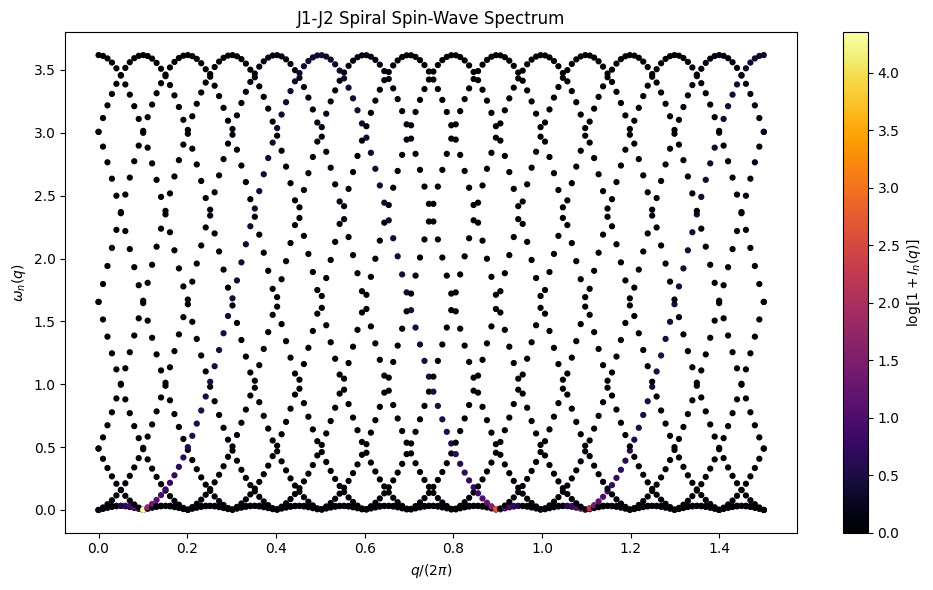

In [53]:
import matplotlib.pyplot as plt

q_plot = np.repeat(
    q_values / (2.0 * np.pi),
    M
)

energy_plot = positive_energies.reshape(-1)

weight_plot = neutron_mode_weights.reshape(-1)

# Skala log hanya untuk visualisasi warna.
# Data neutron_mode_weights tidak diubah.
color_plot = np.log1p(weight_plot)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    q_plot,
    energy_plot,
    c=color_plot,
    s=12,
    cmap="inferno"
)

plt.xlabel(r"$q/(2\pi)$")
plt.ylabel(r"$\omega_n(q)$")
plt.title("J1-J2 Spiral Spin-Wave Spectrum")

colorbar = plt.colorbar(scatter)
colorbar.set_label(r"$\log[1+I_n(q)]$")

plt.tight_layout()
plt.show()

**Aproksimasi delta Dirac**

$$
\delta_\sigma(x)=
\frac{e^{-x^2/(2\sigma^2)}}{\sqrt{2\pi}\sigma},
\qquad
\int_{-\infty}^{\infty}\delta_\sigma(x)\,dx=1.
$$

In [54]:
def gaussian_delta(delta_omega, sigma):
    """
    Aproksimasi Gaussian untuk delta Dirac.

    Integral Gaussian terhadap omega sama dengan satu.
    """

    if sigma <= 0.0:
        raise ValueError("sigma harus lebih besar dari nol.")

    normalization = 1.0 / (
        np.sqrt(2.0 * np.pi) * sigma
    )

    exponent = -0.5 * (
        delta_omega / sigma
    ) ** 2

    return normalization * np.exp(exponent)

**Faktor struktur dinamik**

$$
S(q,\omega)=\sum_n I_n(q)
\delta_\sigma[\omega-\omega_n(q)].
$$

In [55]:
def build_sqw(
    energies,
    mode_weights,
    omega_values,
    sigma
):
    """
    Membentuk S(q, omega) dari energi dan bobot mode.

    Parameters
    ----------
    energies : ndarray, shape (n_q, M)
        Energi positif omega_n(q).

    mode_weights : ndarray, shape (n_q, M)
        Bobot neutron I_n(q).

    omega_values : ndarray, shape (n_omega,)
        Grid energi tempat S(q, omega) dihitung.

    sigma : float
        Lebar Gaussian.

    Returns
    -------
    sqw : ndarray, shape (n_q, n_omega)
        Intensitas S(q, omega).

    gaussian_kernels : ndarray, shape (n_q, M, n_omega)
        Gaussian setiap mode. Berguna untuk pemeriksaan.
    """

    energies = np.asarray(
        energies,
        dtype=float
    )

    mode_weights = np.asarray(
        mode_weights,
        dtype=float
    )

    omega_values = np.asarray(
        omega_values,
        dtype=float
    )

    if energies.shape != mode_weights.shape:
        raise ValueError(
            "energies dan mode_weights harus memiliki shape yang sama."
        )

    if energies.ndim != 2:
        raise ValueError(
            "energies harus memiliki shape (n_q, M)."
        )

    if omega_values.ndim != 1:
        raise ValueError(
            "omega_values harus berupa array satu dimensi."
        )

    if not np.all(np.isfinite(energies)):
        raise ValueError(
            "energies mengandung NaN atau infinity."
        )

    if not np.all(np.isfinite(mode_weights)):
        raise ValueError(
            "mode_weights mengandung NaN atau infinity."
        )

    # Bentuk:
    #
    # omega_values[None, None, :] -> (1, 1, n_omega)
    # energies[:, :, None]        -> (n_q, M, 1)
    #
    # Hasil broadcasting:
    # delta_omega                -> (n_q, M, n_omega)
    delta_omega = (
        omega_values[None, None, :]
        - energies[:, :, None]
    )

    gaussian_kernels = gaussian_delta(
        delta_omega,
        sigma
    )

    # Kontraksi langsung menghindari array weighted_kernels tambahan.
    sqw = np.einsum(
        "qnw,qn->qw",
        gaussian_kernels,
        mode_weights,
        optimize=True
    )

    return sqw, gaussian_kernels

**Skala broadening dan energi maksimum**

$$
\sigma_\omega=0.03|J_1|,\qquad
\omega_{\max}=\max_{q,n}\omega_n(q).
$$

In [56]:
sigma_omega = 0.03 * abs(J1)

maximum_energy = np.max(
    positive_energies
)

**Domain frekuensi**

$$
\omega\in[-6\sigma_\omega,\,\omega_{\max}+6\sigma_\omega].
$$

In [57]:
n_omega = 1200

omega_minimum = -6.0 * sigma_omega

omega_maximum = (
    maximum_energy
    + 6.0 * sigma_omega
)

omega_values_full = np.linspace(
    omega_minimum,
    omega_maximum,
    n_omega
)

**Evaluasi pada kisi $(q,\omega)$**

$$
S(q_j,\omega_\ell)=
\sum_{n=1}^{M}I_n(q_j)
\delta_\sigma[\omega_\ell-\omega_n(q_j)].
$$

In [58]:
sqw_full, gaussian_kernels = build_sqw(
    energies=positive_energies,
    mode_weights=neutron_mode_weights,
    omega_values=omega_values_full,
    sigma=sigma_omega
)

**Indeks peta spektral**

$$
\omega_n(q_j):\ (j,n),\qquad
\delta_\sigma[\omega_\ell-\omega_n(q_j)]:\ (j,n,\ell),
$$

$$
S(q_j,\omega_\ell):\ (j,\ell).
$$

In [59]:
print("positive energies:", positive_energies.shape)
print("mode weights:", neutron_mode_weights.shape)
print("Gaussian kernels:", gaussian_kernels.shape)
print("S(q, omega):", sqw_full.shape)

positive energies: (150, 10)
mode weights: (150, 10)
Gaussian kernels: (150, 10, 1200)
S(q, omega): (150, 1200)


**Tensor dinamik dan aturan jumlah**

$$
S^{\alpha\beta}(q,\omega)=
\sum_nS_n^{\alpha\beta}(q)
\delta_\sigma[\omega-\omega_n(q)],
$$

$$
S(q,\omega)=\sum_{\alpha\beta}
P_{\alpha\beta}S^{\alpha\beta}(q,\omega),
$$

$$
\int S(q,\omega)\,d\omega=\sum_nI_n(q).
$$

positive_energies shape : (150, 10)
neutron weights shape   : (150, 10)
Gaussian kernels shape  : (150, 10, 1200)
S(q, omega) shape       : (150, 1200)

Spectral-weight test:
Maximum absolute error : 7.041788308015384e-08
Maximum relative error : 1.0234961388671247e-09



Tensor consistency test:
Maximum contraction error : 2.2737367544323206e-13


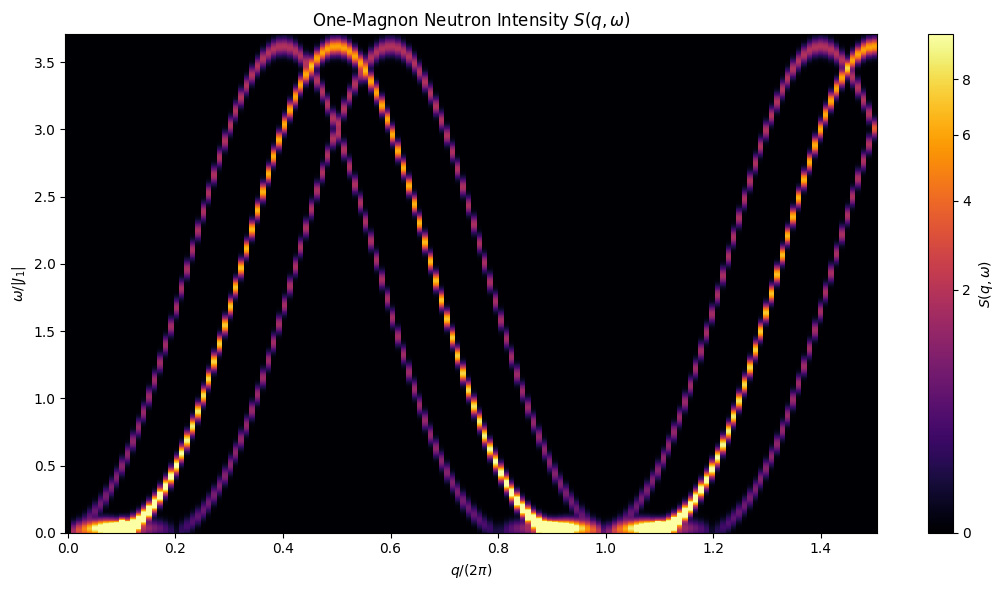

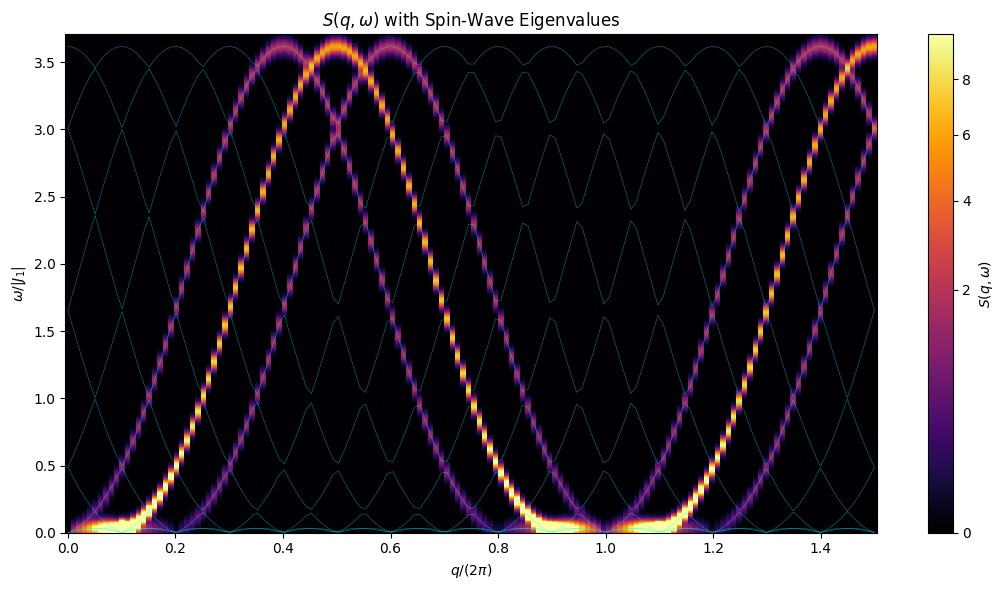

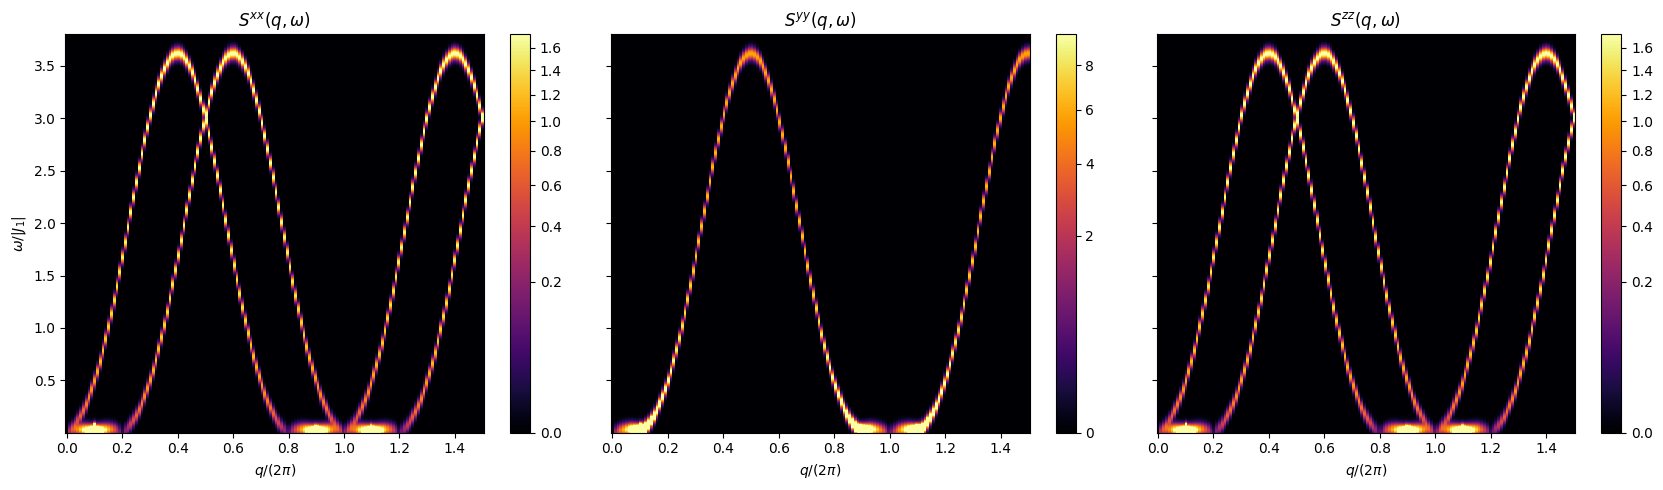


Calculation completed.
q range              : 0.0 to 9.42477796076938
omega range          : 0.002478623337151181 to 3.7980339887498955
Gaussian sigma       : 0.03
Maximum magnon energy: 3.6180339887498953
Minimum S(q,omega)   : 2.626607754998579e-140
Maximum S(q,omega)   : 1146.2509022384627


In [60]:
# ============================================================
# DYNAMIC STRUCTURE FACTOR S(q, omega)
# Validation and visualization using the precomputed Gaussian kernels
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm


# ------------------------------------------------------------
# 1. Aproksimasi delta Dirac menggunakan Gaussian
# ------------------------------------------------------------

def gaussian_delta(delta_omega, sigma):
    if sigma <= 0.0:
        raise ValueError("sigma harus lebih besar dari nol.")

    normalization = 1.0 / (
        np.sqrt(2.0 * np.pi) * sigma
    )

    return normalization * np.exp(
        -0.5 * (delta_omega / sigma) ** 2
    )


# ------------------------------------------------------------
# 2. Membentuk S(q, omega)
# ------------------------------------------------------------

def build_sqw(
    energies,
    mode_weights,
    omega_values,
    sigma
):
    energies = np.asarray(energies, dtype=float)
    mode_weights = np.asarray(mode_weights, dtype=float)
    omega_values = np.asarray(omega_values, dtype=float)

    if energies.ndim != 2:
        raise ValueError(
            "energies harus memiliki shape (n_q, n_modes)."
        )

    if mode_weights.shape != energies.shape:
        raise ValueError(
            "mode_weights harus memiliki shape yang sama "
            "dengan energies."
        )

    if omega_values.ndim != 1:
        raise ValueError(
            "omega_values harus berupa array satu dimensi."
        )

    if not np.all(np.isfinite(energies)):
        raise ValueError(
            "energies mengandung NaN atau infinity."
        )

    if not np.all(np.isfinite(mode_weights)):
        raise ValueError(
            "mode_weights mengandung NaN atau infinity."
        )

    # Shape:
    # omega_values           : (n_omega,)
    # energies               : (n_q, n_modes)
    # delta_omega            : (n_q, n_modes, n_omega)
    delta_omega = (
        omega_values[None, None, :]
        - energies[:, :, None]
    )

    # Gaussian untuk setiap q, mode, dan omega
    gaussian_kernels = gaussian_delta(
        delta_omega,
        sigma
    )

    # S(q,omega) =
    # sum_n I_n(q) delta_sigma[omega - omega_n(q)]
    sqw = np.einsum(
        "qnw,qn->qw",
        gaussian_kernels,
        mode_weights,
        optimize=True
    )

    return sqw, gaussian_kernels


# ============================================================
# 3. PARAMETER GRID ENERGI
# ============================================================

M = n_sites

# Lebar Gaussian dalam satuan energi yang sama dengan J1
sigma_omega = 0.03 * abs(J1)

# Energi maksimum dari seluruh mode
maximum_energy = np.max(
    positive_energies
)

# Jumlah titik grid energi
n_omega = 1200

# Wilayah negatif kecil diperlukan untuk memeriksa
# normalisasi Gaussian pada Goldstone mode omega = 0
omega_values_full = np.linspace(
    -6.0 * sigma_omega,
    maximum_energy + 6.0 * sigma_omega,
    n_omega
)


# ============================================================
# 4. HITUNG S(q, omega)
# ============================================================

# sqw_full and gaussian_kernels were built once in the previous cell.

print("positive_energies shape :", positive_energies.shape)
print("neutron weights shape   :", neutron_mode_weights.shape)
print("Gaussian kernels shape  :", gaussian_kernels.shape)
print("S(q, omega) shape       :", sqw_full.shape)


# ============================================================
# 5. PERIKSA KONSERVASI SPECTRAL WEIGHT
# ============================================================

# Integral S(q,omega) terhadap omega
integrated_weight = np.trapezoid(
    sqw_full,
    x=omega_values_full,
    axis=1
)

# Secara teori integral tersebut harus sama dengan
# jumlah bobot seluruh mode pada q yang sama
expected_weight = np.sum(
    neutron_mode_weights,
    axis=1
)

absolute_weight_error = np.max(
    np.abs(
        integrated_weight
        - expected_weight
    )
)

relative_weight_error = np.max(
    np.abs(
        integrated_weight
        - expected_weight
    )
    / np.maximum(
        np.abs(expected_weight),
        1e-12
    )
)

print()
print("Spectral-weight test:")
print("Maximum absolute error :", absolute_weight_error)
print("Maximum relative error :", relative_weight_error)

assert absolute_weight_error < 1e-6
assert relative_weight_error < 1e-7


# ============================================================
# 6. BENTUK TENSOR DINAMIS S^{alpha beta}(q, omega)
# ============================================================

# mode_tensors memiliki shape:
# (n_q, 3, 3, n_modes)
#
# gaussian_kernels memiliki shape:
# (n_q, n_modes, n_omega)
#
# Hasil:
# (n_q, 3, 3, n_omega)

dynamic_tensor_full = np.einsum(
    "qabn,qnw->qabw",
    mode_tensors,
    gaussian_kernels
)


# ============================================================
# 7. CEK KONTRAKSI TENSOR POLARISASI NEUTRON
# ============================================================

# I(q,omega) =
# sum_{alpha,beta}
# P_{alpha,beta} S^{alpha,beta}(q,omega)

sqw_from_tensor_full = np.einsum(
    "ab,qabw->qw",
    polarization,
    dynamic_tensor_full
).real

tensor_contraction_error = np.max(
    np.abs(
        sqw_from_tensor_full
        - sqw_full
    )
)

print()
print("Tensor consistency test:")
print(
    "Maximum contraction error :",
    tensor_contraction_error
)

assert tensor_contraction_error < 1e-10


# ============================================================
# 8. AMBIL HANYA ENERGI POSITIF
# ============================================================

positive_omega_mask = (
    omega_values_full >= 0.0
)

omega_values = omega_values_full[
    positive_omega_mask
]

sqw = sqw_full[
    :,
    positive_omega_mask
]

dynamic_tensor = dynamic_tensor_full[
    :,
    :,
    :,
    positive_omega_mask
]


# ============================================================
# 9. AMBIL KOMPONEN TENSOR
# ============================================================

Sxx = dynamic_tensor[:, 0, 0, :].real
Syy = dynamic_tensor[:, 1, 1, :].real
Szz = dynamic_tensor[:, 2, 2, :].real

Sxy = dynamic_tensor[:, 0, 1, :]
Sxz = dynamic_tensor[:, 0, 2, :]
Syz = dynamic_tensor[:, 1, 2, :]


# ============================================================
# 10. SIAPKAN SUMBU DAN SKALA WARNA
# ============================================================

q_axis = q_values / (
    2.0 * np.pi
)

positive_intensities = sqw[
    sqw > 0.0
]

if positive_intensities.size > 0:
    color_maximum = np.percentile(
        positive_intensities,
        99.5
    )
else:
    color_maximum = 1.0


# ============================================================
# 11. PLOT S(q, omega)
# ============================================================

plt.figure(figsize=(11, 6))

image = plt.pcolormesh(
    q_axis,
    omega_values,
    sqw.T,
    shading="auto",
    cmap="inferno",
    norm=PowerNorm(
        gamma=0.45,
        vmin=0.0,
        vmax=color_maximum
    )
)

plt.xlabel(r"$q/(2\pi)$")
plt.ylabel(r"$\omega/|J_1|$")
plt.title(
    r"One-Magnon Neutron Intensity $S(q,\omega)$"
)

plt.colorbar(
    image,
    label=r"$S(q,\omega)$"
)

plt.ylim(
    0.0,
    maximum_energy + 3.0 * sigma_omega
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. PLOT S(q, omega) + GARIS DISPERSI
# ============================================================

plt.figure(figsize=(11, 6))

image = plt.pcolormesh(
    q_axis,
    omega_values,
    sqw.T,
    shading="auto",
    cmap="inferno",
    norm=PowerNorm(
        gamma=0.45,
        vmin=0.0,
        vmax=color_maximum
    )
)

for mode in range(M):
    plt.plot(
        q_axis,
        positive_energies[:, mode],
        color="cyan",
        linewidth=0.4,
        alpha=0.5
    )

plt.xlabel(r"$q/(2\pi)$")
plt.ylabel(r"$\omega/|J_1|$")
plt.title(
    r"$S(q,\omega)$ with Spin-Wave Eigenvalues"
)

plt.colorbar(
    image,
    label=r"$S(q,\omega)$"
)

plt.ylim(
    0.0,
    maximum_energy + 3.0 * sigma_omega
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. PLOT Sxx, Syy, DAN Szz
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

spin_components = [
    (Sxx, r"$S^{xx}(q,\omega)$"),
    (Syy, r"$S^{yy}(q,\omega)$"),
    (Szz, r"$S^{zz}(q,\omega)$")
]

for axis, (component, title) in zip(
    axes,
    spin_components
):
    positive_component = component[
        component > 0.0
    ]

    if positive_component.size > 0:
        component_maximum = np.percentile(
            positive_component,
            99.5
        )
    else:
        component_maximum = 1.0

    component_image = axis.pcolormesh(
        q_axis,
        omega_values,
        component.T,
        shading="auto",
        cmap="inferno",
        norm=PowerNorm(
            gamma=0.45,
            vmin=0.0,
            vmax=component_maximum
        )
    )

    axis.set_title(title)
    axis.set_xlabel(r"$q/(2\pi)$")

    fig.colorbar(
        component_image,
        ax=axis
    )

axes[0].set_ylabel(r"$\omega/|J_1|$")

plt.tight_layout()
plt.show()


# ============================================================
# 14. INFORMASI HASIL
# ============================================================

print()
print("Calculation completed.")
print("q range              :", q_values[0], "to", q_values[-1])
print("omega range          :", omega_values[0], "to", omega_values[-1])
print("Gaussian sigma       :", sigma_omega)
print("Maximum magnon energy:", maximum_energy)
print("Minimum S(q,omega)   :", np.min(sqw))
print("Maximum S(q,omega)   :", np.max(sqw))